In [15]:
from music21 import converter, note, chord, interval, pitch
from collections import defaultdict
import os
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [16]:
CIPI_PATH = "/Users/stepanpshenichnyi/Downloads/CIPI_dataset"

In [2]:
from music21 import corpus

beethoven_quartet=corpus.parse('beethoven/opus59no1/movement1.mxl')
key = beethoven_quartet.analyze('key')


In [17]:
CIPI_PATH = "/Users/stepanpshenichnyi/Downloads/CIPI_dataset"

# Markov dictionary: {current_note_midi: {next_note_midi: count}}
pitch_markov = defaultdict(lambda: defaultdict(int))

for root, _, files in os.walk(CIPI_PATH):
    for file in files:
        if file.startswith("._"):
            continue
        if not file.lower().endswith((".xml", ".musicxml", ".mid", ".midi")):
            continue

        filepath = os.path.join(root, file)
        try:
            score = converter.parse(filepath)
        except Exception as e:
            print(f"Skipping {file}: {e}")
            continue

        # Analyze key
        try:
            key = score.analyze('key')
        except:
            continue

        # Determine target tonic
        if key.mode == 'major':
            target = pitch.Pitch('C')
        else:
            target = pitch.Pitch('A')

        # Transpose score
        i = interval.Interval(key.tonic, target)
        score = score.transpose(i)

        # Take first part (right hand)
        part = score.parts[0]

        

        MIN_MIDI = 55   # G3 
        MAX_MIDI = 88   # E6

        notes_seq = []
        for n in part.recurse().notes:

            if isinstance(n, note.Note) and MIN_MIDI <= n.pitch.midi <= MAX_MIDI: #IF a single note + range check
                notes_seq.append(n.pitch.midi)

            elif isinstance(n, chord.Chord): #IF a CHORD instance (extract highest note)
                if n.pitches and MIN_MIDI <= max(p.midi for p in n.pitches) <= MAX_MIDI:  #if there are actual pitches + range check
                    notes_seq.append(max(p.midi for p in n.pitches))
                else:
                    continue  # skip empty chord

        # Build first-order Markov chain
        for j in range(len(notes_seq) - 1):
            curr = notes_seq[j]
            nxt = notes_seq[j+1]
            pitch_markov[curr][nxt] += 1

# Normalize probabilities
pitch_markov_prob = {}
for curr, nxt_dict in pitch_markov.items():
    total = sum(nxt_dict.values())
    pitch_markov_prob[curr] = {nxt: count/total for nxt, count in nxt_dict.items()}


with open("markov_dict/pitch_markov_restrictedG3E6.pkl", "wb") as f:
    pickle.dump(pitch_markov_prob, f)

print("Markov model saved. Example transitions for MIDI 60 (C4):")
if 60 in pitch_markov_prob:
    print(pitch_markov_prob[60])
else:
    print("No data for MIDI 60")


/Users/stepanpshenichnyi/music_thesis/lib/python3.13/site-packages/music21/musicxml/xmlToM21.py:5491: MusicXMLWarning: Could not import wedge: Error in getting DynamicWedges
  warnings.warn(f'Could not import {tag}: {excep}', MusicXMLWarning)
/Users/stepanpshenichnyi/music_thesis/lib/python3.13/site-packages/music21/musicxml/xmlToM21.py:5491: MusicXMLWarning: Could not import octave-shift: Error in getting Ottava
  warnings.warn(f'Could not import {tag}: {excep}', MusicXMLWarning)
/Users/stepanpshenichnyi/music_thesis/lib/python3.13/site-packages/music21/musicxml/xmlToM21.py:5491: MusicXMLWarning: Could not import pedal: Error in getting PedalMark
  warnings.warn(f'Could not import {tag}: {excep}', MusicXMLWarning)
/Users/stepanpshenichnyi/music_thesis/lib/python3.13/site-packages/music21/musicxml/xmlToM21.py:4323: MusicXMLWarning: Line <dashes> stop without start
  warnings.warn('Line <' + mxObj.tag + '> stop without start', MusicXMLWarning)
/Users/stepanpshenichnyi/music_thesis/lib/p

Markov model saved. Example transitions for MIDI 60 (C4):
{62: 0.14420332532958818, 59: 0.15149730439903955, 65: 0.04621030217913288, 74: 0.004258596475331854, 71: 0.006614415802111176, 57: 0.0590767000407738, 64: 0.11095002944774159, 60: 0.141122638517646, 55: 0.07171657681330132, 69: 0.029130612059982783, 67: 0.05151089566438635, 68: 0.009377973089294613, 72: 0.04362796176324016, 76: 0.004983463960494722, 58: 0.029175916277805462, 70: 0.004349204910977212, 66: 0.011915009287364654, 61: 0.021927241426176778, 56: 0.016400126851809905, 63: 0.026593575861912744, 79: 0.0033978163367009468, 84: 0.002355819326779323, 75: 0.0012232138812123408, 80: 0.00045304217822679293, 81: 0.0019027771485525303, 82: 0.00027182530693607574, 87: 0.00027182530693607574, 73: 0.0009060843564535859, 77: 0.0019933855841978887, 88: 0.0013138223168576994, 78: 0.00040773796040411363, 86: 0.00022652108911339647, 83: 0.0005889548316948308, 85: 4.530421782267929e-05}


In [18]:
with open('markov_dict/pitch_markov_restrictedG3E6.pkl', 'rb') as f:
    markov_dict = pickle.load(f)

In [19]:
list(markov_dict.keys())

[69,
 71,
 72,
 74,
 76,
 81,
 80,
 79,
 78,
 77,
 75,
 86,
 85,
 84,
 83,
 82,
 88,
 68,
 87,
 70,
 57,
 59,
 60,
 62,
 64,
 67,
 66,
 65,
 73,
 61,
 63,
 55,
 58,
 56]

In [24]:
markov_dict[60]

{62: 0.14420332532958818,
 59: 0.15149730439903955,
 65: 0.04621030217913288,
 74: 0.004258596475331854,
 71: 0.006614415802111176,
 57: 0.0590767000407738,
 64: 0.11095002944774159,
 60: 0.141122638517646,
 55: 0.07171657681330132,
 69: 0.029130612059982783,
 67: 0.05151089566438635,
 68: 0.009377973089294613,
 72: 0.04362796176324016,
 76: 0.004983463960494722,
 58: 0.029175916277805462,
 70: 0.004349204910977212,
 66: 0.011915009287364654,
 61: 0.021927241426176778,
 56: 0.016400126851809905,
 63: 0.026593575861912744,
 79: 0.0033978163367009468,
 84: 0.002355819326779323,
 75: 0.0012232138812123408,
 80: 0.00045304217822679293,
 81: 0.0019027771485525303,
 82: 0.00027182530693607574,
 87: 0.00027182530693607574,
 73: 0.0009060843564535859,
 77: 0.0019933855841978887,
 88: 0.0013138223168576994,
 78: 0.00040773796040411363,
 86: 0.00022652108911339647,
 83: 0.0005889548316948308,
 85: 4.530421782267929e-05}

          55        56        57        58        59        60        61  \
55  0.276739  0.039138  0.118523  0.030661  0.089685  0.147203  0.008556   
56  0.128998  0.174882  0.160199  0.065810  0.099895  0.094389  0.031463   
57  0.193284  0.048571  0.141315  0.043174  0.153908  0.131121  0.018989   
58  0.086388  0.066393  0.139964  0.126891  0.094335  0.117406  0.040246   
59  0.085361  0.028683  0.132123  0.024106  0.105653  0.238310  0.023648   
60  0.071717  0.016400  0.059077  0.029176  0.151497  0.141123  0.021927   
61  0.021022  0.026776  0.040938  0.035185  0.067050  0.084311  0.096039   
62  0.043276  0.008548  0.032804  0.012262  0.071381  0.195793  0.038622   
63  0.024189  0.015240  0.014541  0.018876  0.027405  0.085850  0.045302   
64  0.023051  0.005424  0.018373  0.005085  0.024678  0.076271  0.015458   
65  0.016365  0.007777  0.014552  0.006632  0.021995  0.032540  0.012167   
66  0.006309  0.004535  0.011337  0.003845  0.016266  0.024152  0.007295   
67  0.018815

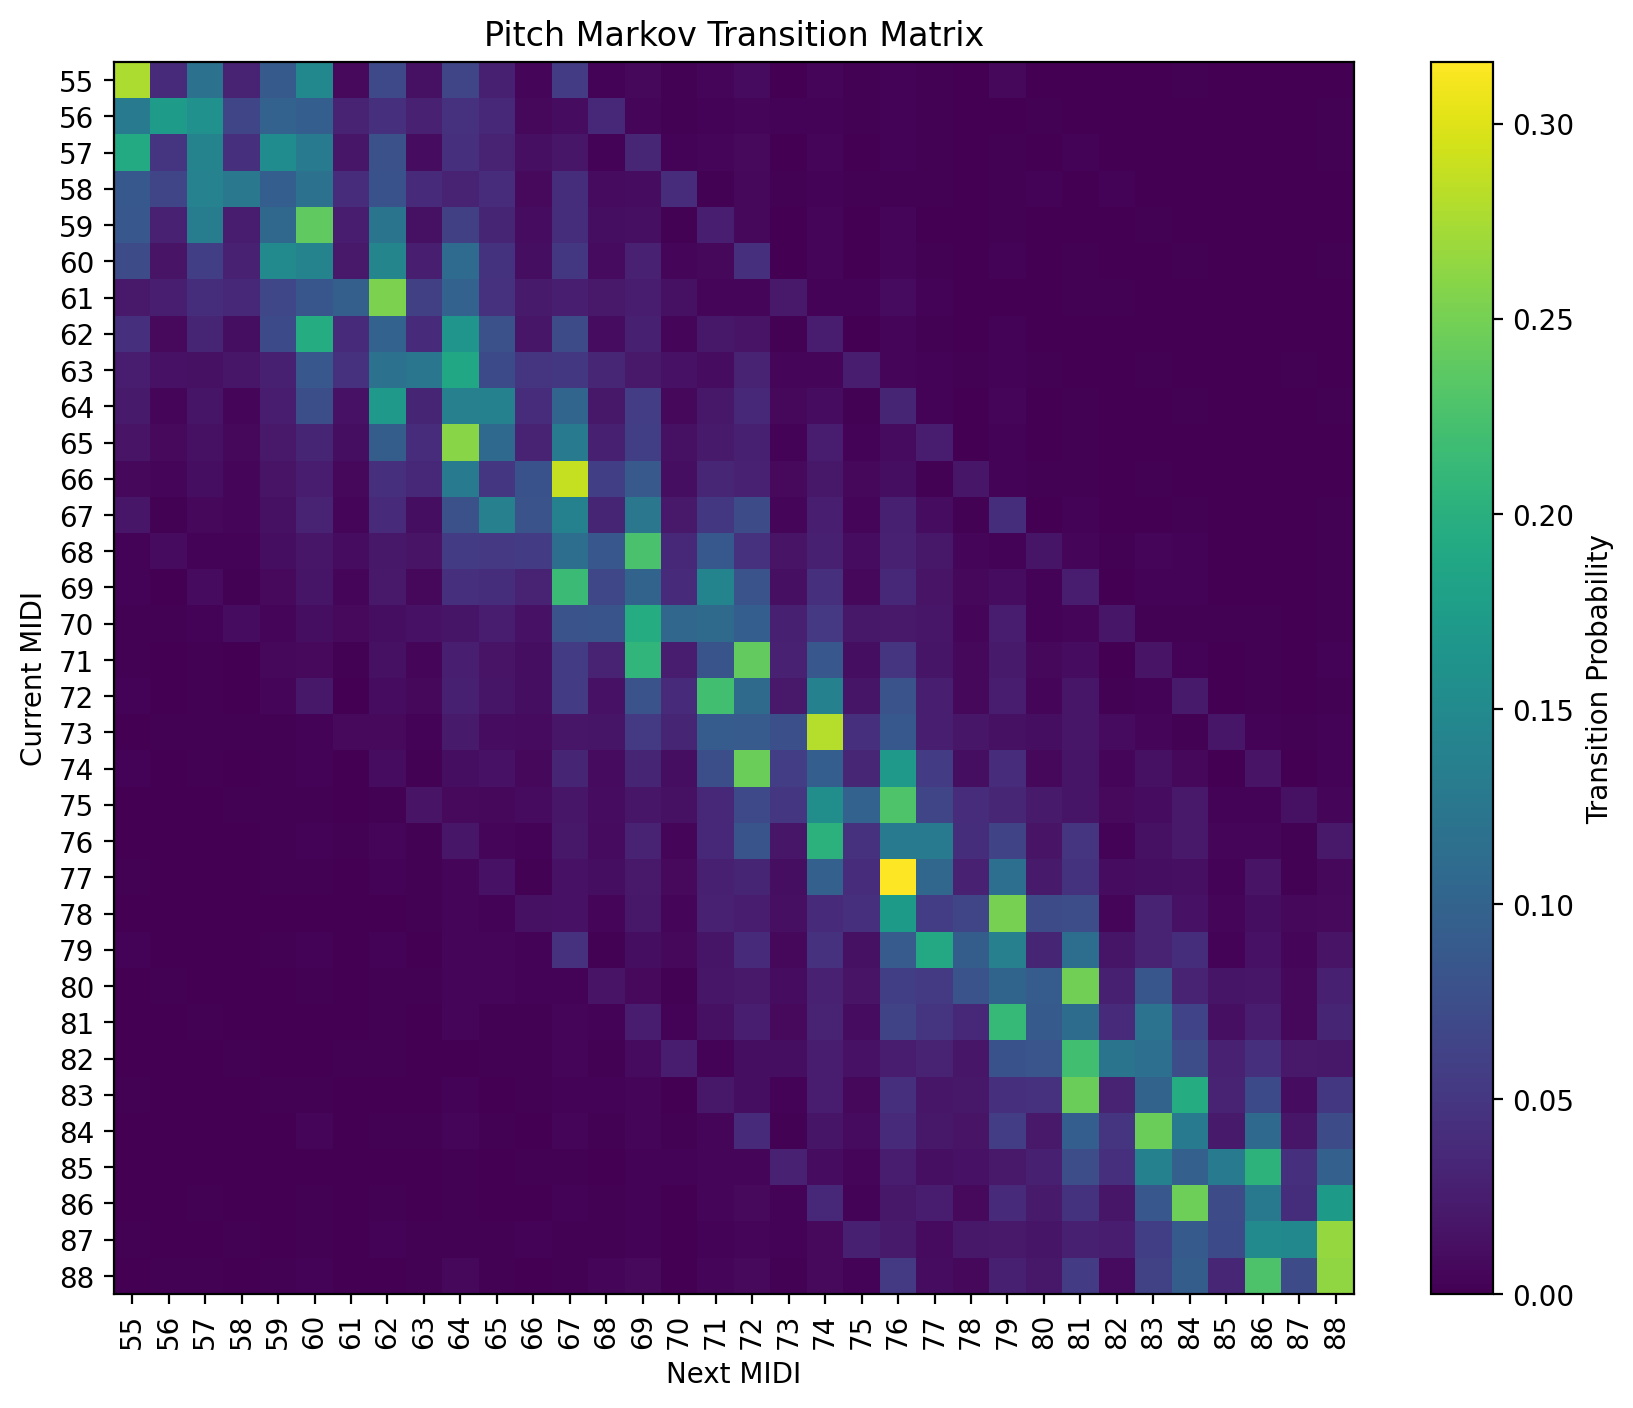

In [ ]:
pitch_markov_prob=markov_dict
states = sorted(pitch_markov_prob.keys())

matrix = pd.DataFrame(0.0, index=states, columns=states)


for curr, transitions in pitch_markov_prob.items():
    for nxt, prob in transitions.items():
        matrix.loc[curr, nxt] = prob

print(matrix)

plt.figure(figsize=(10,8))
plt.imshow(matrix.values, aspect='auto')
plt.colorbar(label="Transition Probability")
plt.xlabel("Next MIDI")
plt.ylabel("Current MIDI")
plt.xticks(range(len(states)), states, rotation=90)
plt.yticks(range(len(states)), states)
plt.title("Pitch Markov Transition Matrix")
plt.show()